# STANDARD: has the earlier high held, and what would a recovery require?

**Updated evidence: September 15, 2026, 22:45:58 UTC.** Hours and days remain relative to this pin; calendar labels are UTC.

This notebook adds a short-horizon flow projection to the earlier agent research. It replaces the starting price, liquidity ranges, fees, pending rewards, vault state and measured turnover with a fresh, consistent on-chain observation. **It does not refit the older agents' unobserved budgets or assign probabilities to future behavior.** The original notebooks remain historical experiments.

A 10% bounce, reclaiming the 13:40 reference and reclaiming the 10:09 reference are different outcomes. Neither reference is asserted to be the all-time high. We have not reconstructed the full price history, and cannot estimate the probability that the ultimate top has occurred.

**Decision read:** current net selling and inactive buybacks favor caution about a prompt full recovery. A bounce remains plausible if selling exhausts itself. A prior high can remain the top while the token has several sizable rallies. Scenario counts are not probabilities.


In [1]:
from pathlib import Path
from dataclasses import replace, asdict
import json, hashlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), Path.cwd()/'research'/'standard-exit'] if (p/'recovery_model.py').exists())
sys.path.insert(0, str(ROOT))
import recovery_model as rm
from time_display import utc_axis, utc_at
e = rm.load_evidence(ROOT)
OUT = ROOT/'recovery-results'; OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 30)
pool = rm.pool_for(e)
print('Pin:', utc_at(e['timestamp']), 'block', e['summary']['block'])
print('Token:', e['summary']['token'], 'chain:', e['summary']['chainId'])
print('Price ETH:', pool.price)
print('Actual ETH principal:', pool.available_eth, '| active virtual ETH:', pool.eth)
print('Measured 40-minute buy spending, before hook tax, ETH/hour:', e['buy_wallet_eth_hour'])
print('Measured token selling/hour:', e['sell_tokens_hour'])
print('Next license reset:', utc_at(e['timestamp'], e['reset_hour']), '| +hours:', e['reset_hour'])
print('Epoch scheduled end:', utc_at(pd.Timestamp(int(e['policy']['bank.epochEnd']), unit='s', tz='UTC')))
display(pd.DataFrame(e['summary']['windows'])[['label','startUTC','endUTC','buysETH','sellsETH','priceChangePct','withdrawals']])


Pin: 2026-09-15 22:45:58 UTC block 64018215
Token: 0x88ad8DdF1E3898412146a534538d418c6F8A9062 chain: 4663
Price ETH: 0.00011446474352696986
Actual ETH principal: 2424.757715411276 | active virtual ETH: 3522.8234347574326
Measured 40-minute buy spending, before hook tax, ETH/hour: 35.13314769581377
Measured token selling/hour: 1558695.6426744626
Next license reset: 2026-09-16 01:04:04 UTC | +hours: 2.3016666666666667
Epoch scheduled end: 2026-09-18 01:00:30 UTC


,label,startUTC,endUTC,buysETH,sellsETH,priceChangePct,withdrawals
0,previous_20m,2026-09-15T22:05:58.000Z,2026-09-15T22:25:58.000Z,10.379727,80.116389,-3.818111,0
1,last_20m,2026-09-15T22:25:58.000Z,2026-09-15T22:45:58.000Z,12.573929,40.713072,-1.585411,0
2,last_5m,2026-09-15T22:40:58.000Z,2026-09-15T22:45:58.000Z,0.058060,0.933761,-0.049730,0


## 1. Minimum buying required through the actual liquidity curve

These are **buy-only lower bounds**, including the observed 2% buy tax and 1% LP fee. Continuing sales increase the necessary expenditure. The token is priced against ETH; this does not forecast ETH/USD. Actual principal and active virtual reserves are kept separate. Existing locked protocol positions were rechecked unchanged and remain safe by assumption; no future LP withdrawal is modeled.


,target,target_price_eth,gain_pct,additional_pool_principal_eth,wallet_buy_eth_no_sellers
0,10% bounce,0.000126,10.000000,172.969428,178.282239
1,25% bounce,0.000143,25.000000,414.089131,426.808010
2,Reclaim 13:40 UTC reference,0.000149,30.442157,496.909128,512.171849
3,Reclaim 10:09 UTC reference,0.000185,61.568163,942.349540,971.294104


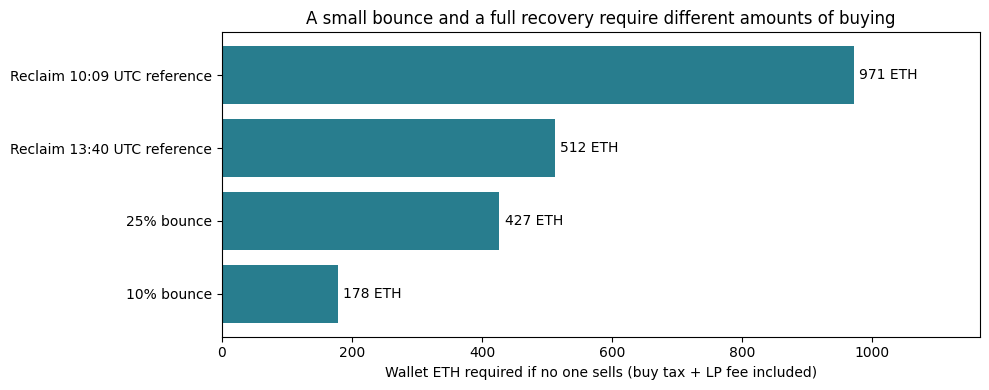

In [2]:
costs = rm.thresholds(e)
display(costs.round(6))
costs.to_csv(OUT/'recovery-thresholds.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(costs.target, costs.wallet_buy_eth_no_sellers, color='#287d8e')
ax.set_xlabel('Wallet ETH required if no one sells (buy tax + LP fee included)')
ax.set_title('A small bounce and a full recovery require different amounts of buying')
for i, value in enumerate(costs.wallet_buy_eth_no_sellers): ax.text(value+8, i, f'{value:,.0f} ETH', va='center')
ax.set_xlim(0, costs.wallet_buy_eth_no_sellers.max()*1.2)
fig.tight_layout(); fig.savefig(OUT/'recovery-costs.png', dpi=160); plt.show()


### How much buying could the next license allocation generate?

The current quota is exhausted and the next reset is shown above. This is a cap on new licenses, not a cap on speculative token buying. The table assumes all 100 licenses clear, and quotes the fresh-funded portion through the current pool. It is a counterfactual demand budget, not a prediction of the auction's price or fill rate. The opening-price case uses twice the last sale; the floor illustration uses two days of the current per-branch issuance. Actual clearing depends on auction sequence and time.


In [3]:
license_rows=[]
last_sale=int(e['state']['license.lastSalePrice'])/1e18
floor_illustration=(int(e['state']['bank.baseIssuancePerDay'])/1e18)*(int(e['state']['bank.multiplierWad'])/1e18)/int(e['state']['bank.totalBranches'])*int(e['auctions']['license.floorPaybackDays'])
for label,qty in [('Illustrative next floor',floor_illustration),('Last observed sale',last_sale),('Implied next opening',last_sale*int(e['auctions']['license.startMultiplier']))]:
    for fraction in [.2,1.]:
        tokens=100*qty*fraction
        license_rows.append(dict(assumed_average_price=label,tokens_per_license=qty,licenses=100,fresh_fraction=fraction,
            fresh_tokens=tokens,wallet_eth_at_current_pool=rm.pool_for(e).quote_buy(tokens),
            reset_utc=utc_at(e['timestamp'],e['reset_hour'])))
license_budget=pd.DataFrame(license_rows);display(license_budget.round(3))
license_budget.to_csv(OUT/'license-demand-budget.csv',index=False)


,assumed_average_price,tokens_per_license,licenses,fresh_fraction,fresh_tokens,wallet_eth_at_current_pool,reset_utc
0,Illustrative next floor,1273.885,100,0.2,25477.707,3.008,2026-09-16 01:04:04 UTC
1,Illustrative next floor,1273.885,100,1.0,127388.535,15.092,2026-09-16 01:04:04 UTC
2,Last observed sale,11888.341,100,0.2,237766.819,28.270,2026-09-16 01:04:04 UTC
3,Last observed sale,11888.341,100,1.0,1188834.093,145.887,2026-09-16 01:04:04 UTC
4,Implied next opening,23776.682,100,0.2,475533.637,56.984,2026-09-16 01:04:04 UTC
5,Implied next opening,23776.682,100,1.0,2377668.186,303.896,2026-09-16 01:04:04 UTC


## 2. Explicit future-flow assumptions

The starting rates use the two adjacent twenty-minute windows, not the overlapping five-minute window. Purchases are measured ETH spending; sales are token quantities. A falling price therefore reduces the ETH received for the same token quantity. Input/output taxes and range crossings are executed by the curve.

**No case below is a fitted forecast.** Extrapolating 40 minutes over 48 hours is a stress test. Sustained buying requires continued spending, and sellers' remaining inventory and willingness are not known. A half-life describes an assumed decline in selling activity, not a measured lockup or unlock.

License cases assume 100 purchases per reset at the last observed price as an illustrative average. Actual sequential auction clearing prices, funding allocation among owners and purchase times are unknown. Internal ledger spending cannot exceed available aggregate earnings; per-owner eligibility is not solved here. Ledger funding creates no market buy. New ETH Charters remain disabled.

Buybacks are off by default because `lastTickAt` is zero. The enabled case assumes execution gates permit hourly purchases, respecting observed spend caps and the finite vault. It does not assume an expansion-vault transfer, tax-funded refill or POL deployment. Taxes collected are not recycled into additional purchases in this overlay.

Issuance continues into the internal ledger at the observed rate; it does not automatically become market selling. The withdrawal stress retires half the branches at +6h, applies the congestion fee and immediately sells the net mint. This is aggregate stress, not the full cohort decision model. The scheduled epoch end is September 18, 2026, 01:00:30 UTC, beyond this 48-hour horizon. The model rejects projections extending to that unsettled boundary; multiplier changes, recycled issuance and new policy allocations would require fresh inputs. The 24-hour results involve less extrapolation of the brief flow sample.


In [4]:
configs = rm.default_scenarios()
assumptions = pd.DataFrame([asdict(c) for c in configs])
display(assumptions)
assumptions.to_csv(OUT/'scenario-assumptions.csv', index=False)
paths = {c.name: rm.simulate(e, c) for c in configs}
summary = rm.summarize(e, paths)
display(summary[['scenario','price_ratio_6h','price_ratio_24h','price_ratio_48h','low_h','low_utc',
                 'speculative_buy_eth','license_buy_eth','buyback_eth']].round(4))
summary.to_csv(OUT/'scenario-summary.csv', index=False)
pd.concat([f.assign(scenario=name) for name,f in paths.items()], ignore_index=True).to_csv(OUT/'scenario-paths.csv', index=False)


,name,hours,dt,buy_multiple,sell_multiple,sell_half_life_hours,buy_half_life_hours,buybacks,license_fill,license_external_fraction,license_tokens_each,license_delay_hours,withdrawal_fraction,withdrawal_hour,sell_first
0,Observed turnover persists,48,0.25,1,1,NaN,NaN,False,0,0.0,11888.340929,0,0.0,6,False
1,Selling halves every 6h,48,0.25,1,1,6.0,NaN,False,0,0.0,11888.340929,0,0.0,6,False
2,Rapid seller exhaustion: 2h,48,0.25,1,1,2.0,NaN,False,0,0.0,11888.340929,0,0.0,6,False
3,Demand fades too,48,0.25,1,1,6.0,6.0,False,0,0.0,11888.340929,0,0.0,6,False
4,Buying triples; selling halves in 6h,48,0.25,3,1,6.0,NaN,False,0,0.0,11888.340929,0,0.0,6,False
5,6h selling decay + buybacks,48,0.25,1,1,6.0,NaN,True,0,0.0,11888.340929,0,0.0,6,False
6,"6h decay + 100 licenses, 20% fresh-funded",48,0.25,1,1,6.0,NaN,False,1,0.2,11888.340929,0,0.0,6,False
7,"6h decay + 100 licenses, fully fresh-funded",48,0.25,1,1,6.0,NaN,False,1,1.0,11888.340929,0,0.0,6,False
8,6h decay + half of branches retire at +6h,48,0.25,1,1,6.0,NaN,False,0,0.0,11888.340929,0,0.5,6,False


,scenario,price_ratio_6h,price_ratio_24h,price_ratio_48h,low_h,low_utc,speculative_buy_eth,license_buy_eth,buyback_eth
0,Observed turnover persists,0.6563,0.3255,0.2289,48.00,2026-09-17 22:45:58 UTC,1686.3911,0.0000,0.0000
1,Selling halves every 6h,0.7540,0.8165,1.2411,11.50,2026-09-16 10:15:58 UTC,1686.3911,0.0000,0.0000
2,Rapid seller exhaustion: 2h,0.8851,1.2070,1.7814,4.50,2026-09-16 03:15:58 UTC,1686.3911,0.0000,0.0000
3,Demand fades too,0.7285,0.5832,0.5680,48.00,2026-09-17 22:45:58 UTC,302.9305,0.0000,0.0000
4,Buying triples; selling halves in 6h,0.9357,1.6448,3.7258,4.25,2026-09-16 03:00:58 UTC,5059.1733,0.0000,0.0000
5,6h selling decay + buybacks,0.7695,0.8556,1.2931,11.00,2026-09-16 09:45:58 UTC,1686.3911,0.0000,110.7992
6,"6h decay + 100 licenses, 20% fresh-funded",0.7638,0.8237,1.2643,11.50,2026-09-16 10:15:58 UTC,1686.3911,48.3263,0.0000
7,"6h decay + 100 licenses, fully fresh-funded",0.8048,0.8538,1.3654,11.75,2026-09-16 10:30:58 UTC,1686.3911,253.4184,0.0000
8,6h decay + half of branches retire at +6h,0.7335,0.8012,1.2232,11.25,2026-09-16 10:00:58 UTC,1686.3911,0.0000,0.0000


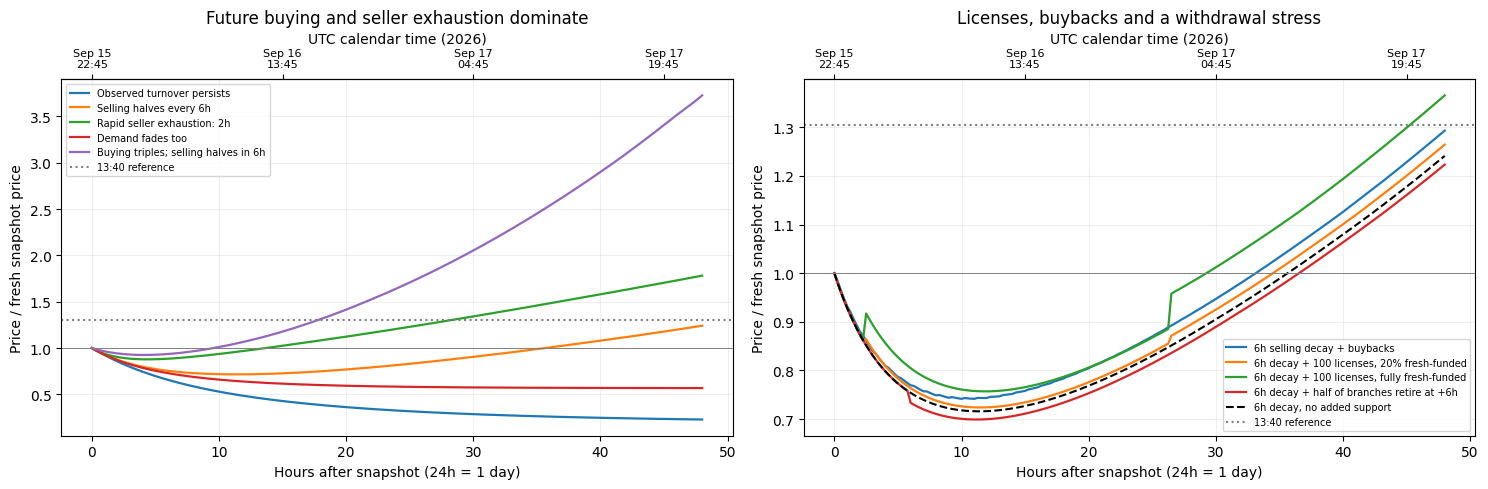

In [5]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
for i, (name, frame) in enumerate(paths.items()):
    ax = axes[0] if i < 5 else axes[1]
    ax.plot(frame.hour, frame.price_ratio, label=name, linewidth=1.6)
axes[1].plot(paths[configs[1].name].hour, paths[configs[1].name].price_ratio, '--', color='black', label='6h decay, no added support')
for ax in axes:
    ax.axhline(1, color='grey', linewidth=.7)
    ax.axhline(e['references']['Reclaim 13:40 UTC reference']/e['price'], color='grey', linestyle=':', label='13:40 reference')
    ax.set(xlabel='Hours after snapshot (24h = 1 day)', ylabel='Price / fresh snapshot price')
    ax.grid(alpha=.2); ax.legend(fontsize=7); utc_axis(ax,e['timestamp'])
axes[0].set_title('Future buying and seller exhaustion dominate')
axes[1].set_title('Licenses, buybacks and a withdrawal stress')
fig.tight_layout(); fig.savefig(OUT/'recovery-scenarios.png', dpi=160); plt.show()


## 3. Sensitivity: do not turn a chosen scenario mix into odds

Cells show the terminal price at +24h relative to the new snapshot. Rows vary the unobserved persistence of selling; columns vary buying relative to the measured starting rate. The grid does not assign likelihood to any cell. All use identical pinned liquidity and fees, with no automatic buyback or license demand.


buy_multiple,0.5,1.0,2.0,3.0
selling_half_life,,,,
2h,0.973,1.207,1.761,2.410
6h,0.648,0.816,1.196,1.645
12h,0.468,0.589,0.864,1.168
Persists,0.260,0.326,0.469,0.624


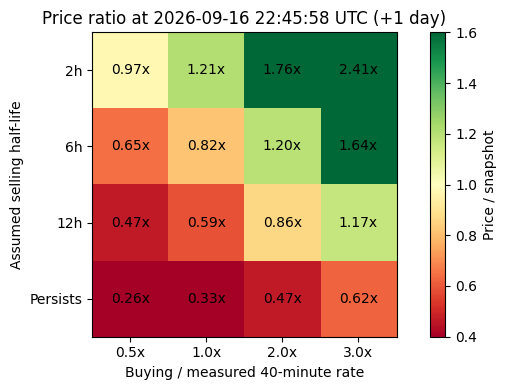

In [6]:
grid=[]
for half in [2,6,12,None]:
    for multiple in [.5,1,2,3]:
        c=rm.Scenario(hours=24,buy_multiple=multiple,sell_half_life_hours=half)
        f=rm.simulate(e,c)
        grid.append(dict(selling_half_life='Persists' if half is None else f'{half}h',buy_multiple=multiple,
                         final_ratio=f.iloc[-1].price_ratio,scenario_end_utc=f.iloc[-1].timestamp_utc))
sensitivity=pd.DataFrame(grid)
sensitivity.to_csv(OUT/'flow-sensitivity.csv',index=False)
matrix=sensitivity.pivot(index='selling_half_life',columns='buy_multiple',values='final_ratio').reindex(['2h','6h','12h','Persists'])
display(matrix.round(3))
fig,ax=plt.subplots(figsize=(7,4))
im=ax.imshow(matrix.to_numpy(),cmap='RdYlGn',vmin=.4,vmax=1.6)
ax.set_xticks(range(len(matrix.columns)),[str(x)+'x' for x in matrix.columns]); ax.set_yticks(range(len(matrix.index)),matrix.index)
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)): ax.text(j,i,f'{matrix.iloc[i,j]:.2f}x',ha='center',va='center')
ax.set(xlabel='Buying / measured 40-minute rate',ylabel='Assumed selling half-life',title='Price ratio at '+utc_at(e['timestamp'],24)+' (+1 day)')
fig.colorbar(im,ax=ax,label='Price / snapshot');fig.tight_layout();fig.savefig(OUT/'flow-sensitivity.png',dpi=160);plt.show()


## 4. Turn recovery targets into falsifiable flow requirements

For each selling-persistence assumption, solve for the constant hourly buying needed to finish +24h at the target. These are conditional expenditure requirements, not available cash or forecasts. Buybacks and licenses are excluded to avoid counting assumed demand as measured demand.


In [7]:
required=[]
for half in [2,6,12,None]:
    for target in ['10% bounce','Reclaim 13:40 UTC reference','Reclaim 10:09 UTC reference']:
        lo,hi=0.,20.
        for _ in range(30):
            mid=(lo+hi)/2
            f=rm.simulate(e,rm.Scenario(hours=24,buy_multiple=mid,sell_half_life_hours=half))
            if f.iloc[-1].price < e['references'][target]:lo=mid
            else:hi=mid
        required.append(dict(selling_half_life='Persists' if half is None else f'{half}h',target=target,
            hourly_wallet_buy_eth=hi*e['buy_wallet_eth_hour'],multiple_of_observed=hi,
            total_wallet_buy_eth_24h=hi*e['buy_wallet_eth_hour']*24,
            target_time_utc=utc_at(e['timestamp'],24)))
required=pd.DataFrame(required);display(required.round(2))
required.to_csv(OUT/'required-buying.csv',index=False)


,selling_half_life,target,hourly_wallet_buy_eth,multiple_of_observed,total_wallet_buy_eth_24h,target_time_utc
0,2h,10% bounce,27.39,0.78,657.41,2026-09-16 22:45:58 UTC
1,2h,Reclaim 13:40 UTC reference,41.78,1.19,1002.62,2026-09-16 22:45:58 UTC
2,2h,Reclaim 10:09 UTC reference,61.56,1.75,1477.50,2026-09-16 22:45:58 UTC
3,6h,10% bounce,61.92,1.76,1486.09,2026-09-16 22:45:58 UTC
4,6h,Reclaim 13:40 UTC reference,79.20,2.25,1900.90,2026-09-16 22:45:58 UTC
5,6h,Reclaim 10:09 UTC reference,103.23,2.94,2477.43,2026-09-16 22:45:58 UTC
6,12h,10% bounce,97.92,2.79,2350.17,2026-09-16 22:45:58 UTC
7,12h,Reclaim 13:40 UTC reference,119.76,3.41,2874.33,2026-09-16 22:45:58 UTC
8,12h,Reclaim 10:09 UTC reference,150.75,4.29,3617.89,2026-09-16 22:45:58 UTC
9,Persists,10% bounce,204.59,5.82,4910.25,2026-09-16 22:45:58 UTC


## 5. Validation and what would change the assessment

- Sustained net buying over several non-overlapping windows would support a recovery thesis more than a single positive five-minute candle.
- Actual fresh-funded license purchases matter. A sold-out auction funded internally does not establish new ETH demand.
- Successful buyback transactions matter; an idle vault balance is not buy pressure.
- Continuing declines in token sell volume favor seller exhaustion. Renewed large sales or branch withdrawals weaken that case.
- The earlier 10:09 and 13:40 prices are reference levels, not verified all-time highs. No full historical-top classification or statistical posterior is supplied.

The comparison is a short-horizon supplement, not a solved multiplayer equilibrium. It does not know seller cost bases, future capital arrivals, unobserved venue flows or catalysts. A bounce and an already-established earlier top are compatible.


In [8]:
audits=[]
for name,f in paths.items():
    audits.append(dict(scenario=name,max_eth_error=f.eth_error.abs().max(),max_token_error=f.token_error.abs().max(),
                       minimum_stock=f.outside_pool_token_bound.min(),minimum_vault=f.vault_eth.min()))
audit=pd.DataFrame(audits);display(audit)
audit.to_csv(OUT/'accounting-checks.csv',index=False)
base=rm.Scenario(sell_half_life_hours=6)
coarse=rm.simulate(e,base).iloc[-1].price
fine=rm.simulate(e,replace(base,dt=.05)).iloc[-1].price
reversed_order=rm.simulate(e,replace(base,sell_first=True)).iloc[-1].price
print('Final-price sensitivity to 3-minute steps:',fine/coarse-1)
print('Final-price sensitivity to sell-first order:',reversed_order/coarse-1)
assert audit.max_eth_error.max()<1e-6 and audit.max_token_error.max()<.02
metadata=dict(observation=rm.OBSERVATION,block=e['summary']['block'],block_hash=e['summary']['blockHash'],
    timestamp_utc=utc_at(e['timestamp']),calibrated_probabilities=False,scenarios=[asdict(c) for c in configs],
    source_sha256={n:hashlib.sha256((ROOT/n).read_bytes()).hexdigest() for n in ['recovery_model.py','liquidity.py','time_display.py']},
    evidence_sha256={p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(e['folder'].glob('*.json'))},
    time_step_price_relative_difference=fine/coarse-1,execution_order_price_relative_difference=reversed_order/coarse-1)
(OUT/'metadata.json').write_text(json.dumps(metadata,indent=2,allow_nan=False)+'\n')


,scenario,max_eth_error,max_token_error,minimum_stock,minimum_vault
0,Observed turnover persists,5.456968e-12,1.132488e-06,3.475265e+07,111.718994
1,Selling halves every 6h,1.523404e-11,1.341105e-07,6.244699e+07,111.718994
2,Rapid seller exhaustion: 2h,1.409717e-11,7.450581e-08,6.592819e+07,111.718994
3,Demand fades too,1.591616e-12,1.043081e-07,5.808551e+07,111.718994
4,Buying triples; selling halves in 6h,1.773515e-11,7.450581e-08,6.675111e+07,111.718994
5,6h selling decay + buybacks,1.045919e-11,5.960464e-08,6.235452e+07,0.919753
6,"6h decay + 100 licenses, 20% fresh-funded",1.523404e-11,1.043081e-07,6.240273e+07,111.718994
7,"6h decay + 100 licenses, fully fresh-funded",9.322321e-12,1.192093e-07,6.222381e+07,111.718994
8,6h decay + half of branches retire at +6h,1.773515e-11,7.450581e-08,6.250350e+07,111.718994


Final-price sensitivity to 3-minute steps: 0.0009819874206791201
Final-price sensitivity to sell-first order: 0.0024444573899553568


9938